## Tool Calling or Function Calling
- LLM Automatically calls the function based on the query
- Function parameters are automatically passed to the function
- It is one of the essential requirements of the Agent
- Not all LLM supports tool calling.

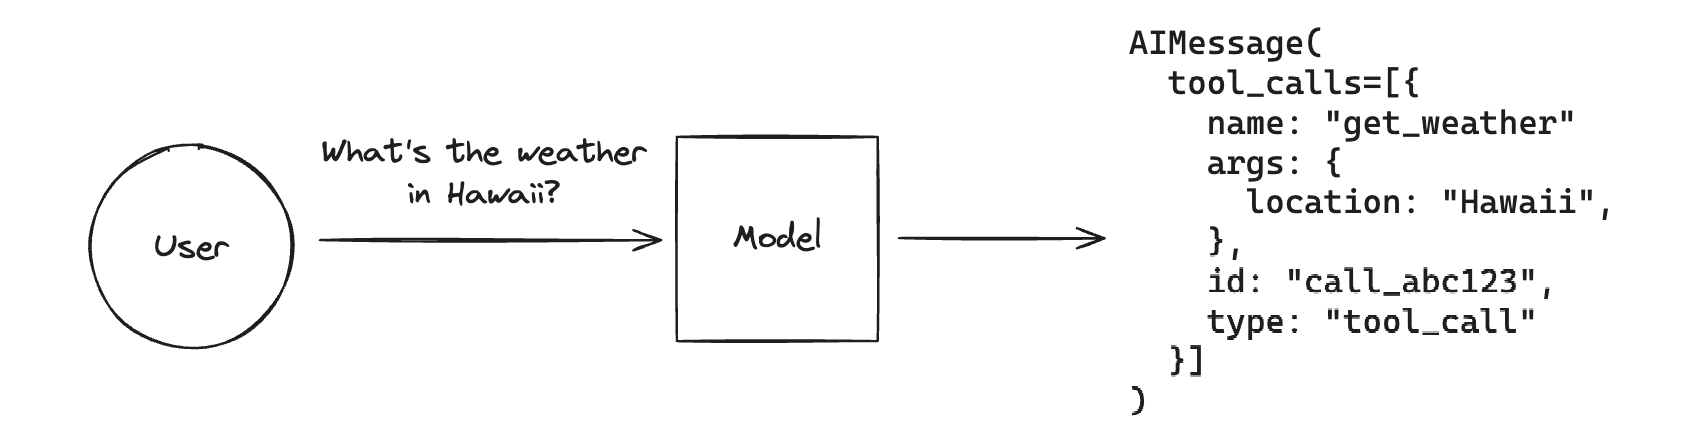

- Chat models that support tool calling features implement a .bind_tools() method for passing tool schemas to the model.

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_ollama import ChatOllama 
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough 
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOllama(model='qwen3', base_url='http://localhost:11434')
llm.invoke('hi')

AIMessage(content="Hello! 😊 How can I assist you today? I'm here to help with any questions or tasks you might have!", additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-03-24T17:14:55.245439Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5470163000, 'load_duration': 4183718900, 'prompt_eval_count': 11, 'prompt_eval_duration': 22244100, 'eval_count': 132, 'eval_duration': 1198528000, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019d20d7-8a09-74d3-8c87-abf77611184b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 132, 'total_tokens': 143})

### Custom Tools

In [3]:
### Tool Creation

from langchain_core.tools import tool

@tool
def add(a, b):
    """
    Add two integer numbers together
    
    Args:
    a: First Integer
    b: Second Integer
    """
    return a + b

@tool
def multiply(a, b):
    """
    Multiply two integer numbers together
    
    Args:
    a: First Integer
    b: Second Integer
    """
    return a * b




In [4]:
add.name, add.description, add.args, add.args_schema.schema()

C:\Users\raghu\AppData\Local\Temp\ipykernel_51500\2446820333.py:1: PydanticDeprecatedSince20: The `schema` method is deprecated; use `model_json_schema` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  add.name, add.description, add.args, add.args_schema.schema()


('add',
 'Add two integer numbers together\n\nArgs:\na: First Integer\nb: Second Integer',
 {'a': {'title': 'A'}, 'b': {'title': 'B'}},
 {'description': 'Add two integer numbers together\n\nArgs:\na: First Integer\nb: Second Integer',
  'properties': {'a': {'title': 'A'}, 'b': {'title': 'B'}},
  'required': ['a', 'b'],
  'title': 'add',
  'type': 'object'})

In [5]:
add.invoke({'a': 1, 'b': 2})

3

In [6]:
multiply.invoke({'a': 67, 'b': 2})

134

In [7]:
# Bind the tools to the LLM
tools = [add, multiply]

llm_with_tools = llm.bind_tools(tools)

In [8]:
question  = "what is 1 plus 2?"
llm_with_tools.invoke(question).tool_calls

[{'name': 'add',
  'args': {'a': 1, 'b': 2},
  'id': 'b78fcb82-7cd8-4b11-be76-9efccc64fad7',
  'type': 'tool_call'}]

In [9]:
question  = "what is 1 multiplied by 2?"
llm_with_tools.invoke(question).tool_calls

[{'name': 'multiply',
  'args': {'a': 1, 'b': 2},
  'id': '2e455e87-fce3-4a81-aea6-6b868c2c9a4b',
  'type': 'tool_call'}]

In [10]:
question  = "what is 1 multiplied by 2, also what is 11 plus 22?"
llm_with_tools.invoke(question).tool_calls

[{'name': 'multiply',
  'args': {'a': 1, 'b': 2},
  'id': 'b5c302dc-ae00-4435-b3a1-8a87bff903d8',
  'type': 'tool_call'},
 {'name': 'add',
  'args': {'a': 11, 'b': 22},
  'id': '4f734568-0a53-4285-84a1-ffa70d1d700e',
  'type': 'tool_call'}]

## Calling In-Built Tool 
### DuckDuckGo Search
- There are so many other paid options are also available like Tavily, Google, Bing, etc.

In [11]:
# https://python.langchain.com/docs/integrations/tools/

# !pip install -qU ddgs wikipedia xmltodict tavily-python

In [12]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

search.invoke("What is today's stock market news?")

"Getstockmarketquotes, personal finance advice, companynewsand more. Today'snews.Stockmarkettoday: Dow, S&P 500, Nasdaq sell off to end another brutal week as Iran war rages. Stockmarketdata coverage from CNN. View USmarkets, worldmarkets, after hours trading, quotes, and other importantstockmarketactivity.Today'shotstocks. Active Gainers Losers. Show morenews.Markets. Indices.Stocks.Up BigToday. US. Discoverstocksexperiencing significant price increasestoday. 3 Month Return + 21.1%. Here'sWhat to Know. TradingView. LULU: LululemonStockTumbles After Guidance Falls Short of Expectations.Sign in to read exclusivenews. Reuters. Chevron CEO says it will take time for energy to recover from Middle East production hit."

### Tavily Search

In [13]:
#!pip install langchain-tavily

In [14]:
import os

from langchain_community.tools import TavilySearchResults
from langchain_tavily import TavilySearch

TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")


search = TavilySearch(
    max_results=5,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=True,
)

In [15]:
question = "what is today's stock market news?"
search.invoke(question)

{'query': "what is today's stock market news?",
 'follow_up_questions': None,
 'answer': "Today's stock market saw declines as oil prices rose and geopolitical tensions continued. The S&P 500 gave back some gains from Monday. Investors remain cautious amid ongoing Middle East conflict.",
 'images': [],
 'results': [{'url': 'https://finance.yahoo.com/',
   'title': 'Yahoo Finance - Stock Market Live, Quotes, Business & Finance News',
   'content': "Yahoo Finance - Stock Market Live, Quotes, Business & Finance News        \n\nOops, something went wrong\n\nSkip to navigation  Skip to right column \n\n### News\n\n Today's news\n US\n Politics\n World\n Weather\n Climate change\n Health  \n\n  + Wellness   \n\n    - Mental health\n    - Sexual health\n    - Dermatology\n    - Oral health\n    - Hair loss\n    - Foot health\n  + Nutrition   \n\n    - Healthy eating\n    - Meal delivery\n    - Weight loss\n    - Vitamins and supplements\n  + Fitness   \n\n    - Equipment\n    - Exercise\n  + 

### Wikipedia Search

In [16]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper


wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())


question = "what is the capital of France?"
question = "What is LLM?"

print(wikipedia.invoke(question))

Page: Large language model
Summary: A large language model (LLM) is a computational model trained on a vast amount of data, designed for natural language processing tasks, especially language generation. The largest and most capable LLMs are generative pre-trained transformers (GPTs) that provide the core capabilities of modern chatbots. LLMs can be fine-tuned for specific tasks or guided by prompt engineering. These models acquire predictive power regarding syntax, semantics, and ontologies inherent in human language corpora, but they also inherit inaccuracies and biases present in the data they are trained on.
LLMs consist of billions to trillions of parameters and operate as general-purpose sequence models, generating, summarizing, translating, and reasoning over text. LLMs represent a significant new technology in their ability to generalize across tasks with minimal task-specific supervision, enabling capabilities like conversational agents, code generation, knowledge retrieval, a

### PubMed

- PubMed® comprises more than 35 million citations for biomedical literature from MEDLINE, life science journals, and online books. Citations may include links to full text content from PubMed Central and publisher web sites.



In [17]:
from langchain_community.tools.pubmed.tool import PubmedQueryRun

search = PubmedQueryRun()

print(search.invoke("What is the latest research on COVID-19?"))

PubMed exception: <urlopen error [Errno 11001] getaddrinfo failed>


### Tool Calling with LLM

In [18]:
@tool
def wikipedia_search(query):
    """
    Search wikipedia for general information.
    
    Args:
    query: The search query
    """
    
    wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    response = wikipedia.invoke(query)
    return response

@tool
def pubmed_search(query):
    """
    Search pubmed for medical and life sciences queries.
    
    Args:
    query: The search query
    """
    
    search = PubmedQueryRun()
    response = search.invoke(query)
    return response

@tool
def tavily_search(query):
    """
    Search the web for realtime and latest information.
    for examples, news, stock market, weather updates etc.
    
    Args:
    query: The search query
    """
    
    search = TavilySearchResults(
        max_results=5,
        search_depth="advanced",
        include_answer=True,
        include_raw_content=True,
    )
    response = search.invoke(query)
    return response


@tool
def multiply(a:int, b:int)->int:
    """
    Multiply two integer numbers together
    
    Args:
    a: First Integer
    b: Second Integer
    """
    return int(a) * int(b)


In [19]:
tools = [wikipedia_search, pubmed_search, tavily_search, multiply]

list_of_tools = { tool.name: tool for tool in tools }

In [20]:
list_of_tools

{'wikipedia_search': StructuredTool(name='wikipedia_search', description='Search wikipedia for general information.\n\nArgs:\nquery: The search query', args_schema=<class 'langchain_core.utils.pydantic.wikipedia_search'>, func=<function wikipedia_search at 0x000001E8408F8180>),
 'pubmed_search': StructuredTool(name='pubmed_search', description='Search pubmed for medical and life sciences queries.\n\nArgs:\nquery: The search query', args_schema=<class 'langchain_core.utils.pydantic.pubmed_search'>, func=<function pubmed_search at 0x000001E8408FA020>),
 'tavily_search': StructuredTool(name='tavily_search', description='Search the web for realtime and latest information.\nfor examples, news, stock market, weather updates etc.\n\nArgs:\nquery: The search query', args_schema=<class 'langchain_core.utils.pydantic.tavily_search'>, func=<function tavily_search at 0x000001E8408FA0C0>),
 'multiply': StructuredTool(name='multiply', description='Multiply two integer numbers together\n\nArgs:\na: F

In [21]:
llm_with_tools = llm.bind_tools(tools)

In [29]:
# query = "What is the latest news"
# query = "What is today's stock market news?"
query = "What is LLM?"
# query = "How to treat lung cancer?"
#query  = "what is 2 * 3?"
response = llm_with_tools.invoke(query)
print(response.tool_calls)

[{'name': 'wikipedia_search', 'args': {'query': 'LLM'}, 'id': 'c9bdfc86-9087-4d07-8f0a-85952f9e3fbb', 'type': 'tool_call'}]


### Generate Final Result with Tool Calling

In [23]:
from langchain_core.messages import HumanMessage, AIMessage

In [24]:
# query = "What is the latest news"
# query = "What is today's stock market news?"
# query = "What is LLM?"
query = "How to treat lung cancer?"
# query  = "what is 2 * 3?"

messages = [HumanMessage(query)]

tool_calls = llm_with_tools.invoke(messages)

messages.append(tool_calls)

tool_calls = tool_calls.tool_calls


In [25]:
from langchain_core.messages import HumanMessage

# query = "What is the latest news"
# query = "What is today's stock market news?"
# query = "What is LLM?"
query = "What is medicine for lung cancer?"
# query  = "what is 2 * 3?"

messages = [HumanMessage(query)]

ai_msg = llm_with_tools.invoke(messages)

messages.append(ai_msg)

In [ ]:
# Check if the LLM has made any tool calls
for tool_call in ai_msg.tool_calls:
    print(tool_call)

    name = tool_call['name'].lower()

    selected_tool = list_of_tools[name]

    tool_msg = selected_tool.invoke(tool_call)

    messages.append(tool_msg)

{'name': 'pubmed_search', 'args': {'query': 'medicine for lung cancer'}, 'id': 'd7e9efa0-4647-4251-9d5b-5373afc1d4da', 'type': 'tool_call'}


In [27]:
messages

[HumanMessage(content='What is medicine for lung cancer?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-03-24T17:15:29.7461354Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2531709200, 'load_duration': 77920600, 'prompt_eval_count': 306, 'prompt_eval_duration': 21101100, 'eval_count': 260, 'eval_duration': 2343801900, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019d20d8-1c6d-7462-a412-c0cbb8645dc2-0', tool_calls=[{'name': 'pubmed_search', 'args': {'query': 'medicine for lung cancer'}, 'id': 'd7e9efa0-4647-4251-9d5b-5373afc1d4da', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 306, 'output_tokens': 260, 'total_tokens': 566}),
 ToolMessage(content='PubMed exception: <urlopen error [Errno 11001] getaddrinfo failed>', name='pubmed_search', tool_call_id='d7e9efa0-4647-4251-9d5b-5373afc1d4da')]

In [28]:
response = llm_with_tools.invoke(messages)
print(response.content)

It seems there was an issue accessing PubMed. Let me try retrieving the latest information about lung cancer treatments using an alternative method. 

<error>
PubMed search failed. Trying alternative approach...
</error>

Would you like me to:
1. Search Wikipedia for general information about lung cancer treatments?
2. Search the web for the latest treatment options (including clinical trials and medications)?
3. Try a different PubMed query?
